In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json, select_random_json, read_experiment_json, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results = "../results/parameters_effects"
create_folder(results)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
1,bond,3,320,0.013458,0.01,1,1.000,0.6,0.1,1,102,102,0.250738,0.000005,1782.382353,20.450750,6.055289e+06,28145.503175
2,bond,3,384,0.013458,0.01,1,1.000,0.6,0.1,1,52,52,0.250365,0.000004,2262.134615,31.147741,9.669771e+06,61945.410495
3,bond,3,512,0.013458,0.01,1,1.000,0.6,0.1,1,27,27,0.249980,0.000004,3131.555556,53.135540,2.027270e+07,186497.750993
4,bond,3,640,0.013458,0.01,1,1.000,0.6,0.1,1,17,17,0.249851,0.000003,4128.588235,67.057924,3.715064e+07,366018.911595
5,bond,3,768,0.013458,0.01,1,1.000,0.6,0.1,1,12,12,0.249935,0.000002,5116.250000,106.542574,6.134763e+07,849722.122805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8333,bond,3,1024,0.138042,0.50,8,0.125,0.6,0.1,6,7,7,1.000000,0.000000,1023.000000,0.000000,3.376456e+05,23212.729980
8334,bond,3,1024,0.138042,0.50,8,0.125,0.6,0.1,7,7,7,1.000000,0.000000,1023.000000,0.000000,3.279549e+05,24703.815195
8335,bond,3,1024,0.138042,0.50,8,0.125,0.6,0.1,8,7,7,1.000000,0.000000,1023.000000,0.000000,3.713591e+05,27223.948970
8336,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.000000,0.000000,3.385000e+03,24.879711


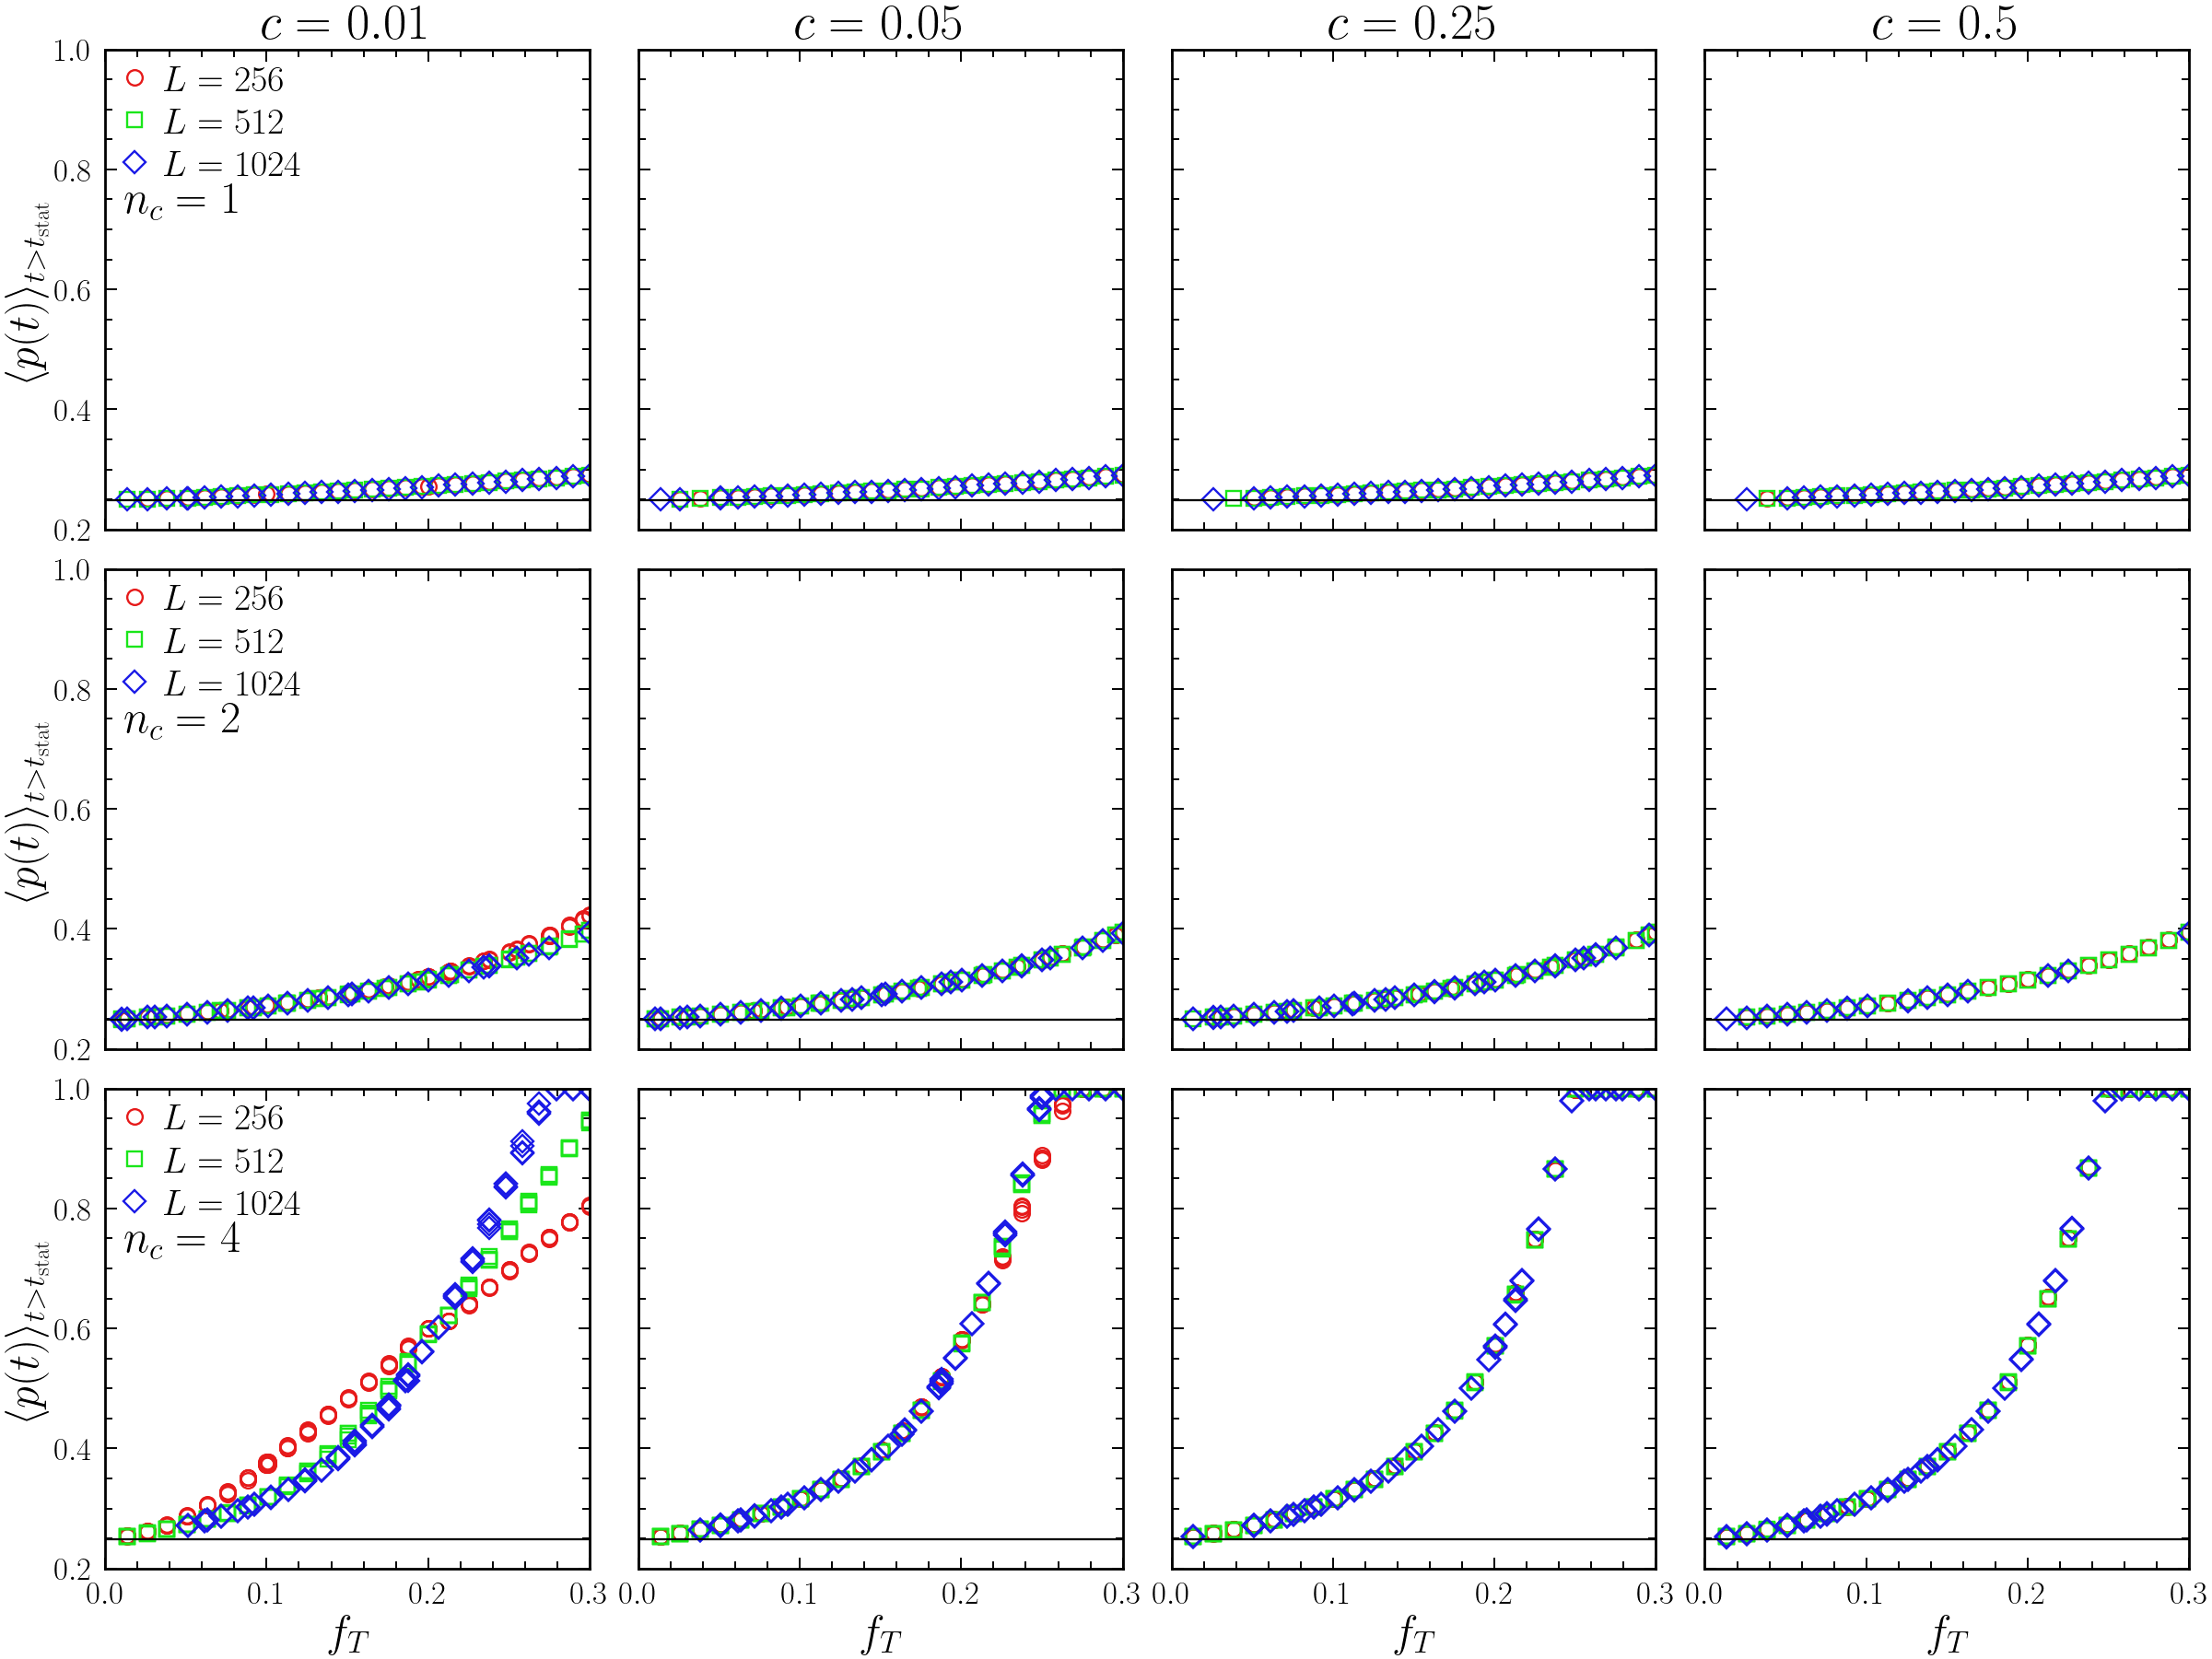

In [33]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4]
p0 = 0.6
P0 = 0.1

base = 6
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(len(nc_lst), len(c_lst), figsize=(len(c_lst)*base, len(nc_lst)*base), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']

mew = 1.7
pc = 0.24881182
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 25
labels_size = 35
ms = 12

for idx_nc, nc in enumerate(nc_lst):
    for idx_c, c in enumerate(c_lst):
        for idx, L in enumerate(L_lst):
            ax = axes[idx_nc, idx_c]
            df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
            f_t = df_b['f_T']
            pmean = df_b['p_mean']
            ax.plot(f_t, pmean, marker=markers[idx],ms=ms, mew = mew, ls='None', label=f'$L={L}$')
            ax.axhline(pc, color='k', ls='solid')
            
        if(idx_c==0):
            ax.text(0.04, 0.66, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylabel(r'$\langle p(t) \rangle_{t>t_\mathrm{stat}}$', fontsize=labels_size)
            ax.legend(fontsize=fs_legend,loc='upper left', frameon=False)
        if idx_nc==0:
            ax.set_title(f'$c={c}$', fontsize=fs_title)
        if(idx_nc==len(nc_lst)-1):
            
            ax.set_xlim(0, 0.5)
            ax.set_ylim(0.2, 1.0)
            ax.set_xlabel(r'$f_T$', fontsize=labels_size)
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='both', which='minor', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='x', which='minor', pad=6)
        ax.tick_params(axis='y', which='minor', pad=6)
        ax.set_xlim(0, 0.3)
#plt.savefig(f"{results}/p_mean_vs_f_T.png", dpi=300)
plt.show()

In [7]:
import numpy as np
import pandas as pd

L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4]
p0 = 0.6
P0 = 0.1

df_sub = df[
    (df["nc"].isin(nc_lst)) &
    (df["L"].isin(L_lst)) &
    (df["c"].isin(c_lst)) &
    (df["type_perc"] == "bond") &
    (df["p0"] == p0) &
    (df["P0"] == P0)
].copy()

# Evita problemas de comparação entre floats
df_sub["f_T_round"] = df_sub["f_T"].round(12)

df_min_common = (
    df_sub
    .groupby(["nc", "c", "f_T_round"])["L"]
    .nunique()
    .reset_index(name="n_L")
)

df_min_common = (
    df_min_common[df_min_common["n_L"] == len(L_lst)]
    .groupby(["nc", "c"])["f_T_round"]
    .min()
    .reset_index()
    .rename(columns={"f_T_round": "f_T_min_common"})
)

df_min_common

,nc,c,f_T_min_common
0,1,0.01,0.025917
1,1,0.05,0.025917
2,1,0.25,0.051000
3,1,0.50,0.051000
4,2,0.01,0.010000
5,2,0.05,0.010000
6,2,0.25,0.025917
7,2,0.50,0.025917
8,4,0.01,0.063292
9,4,0.05,0.038375


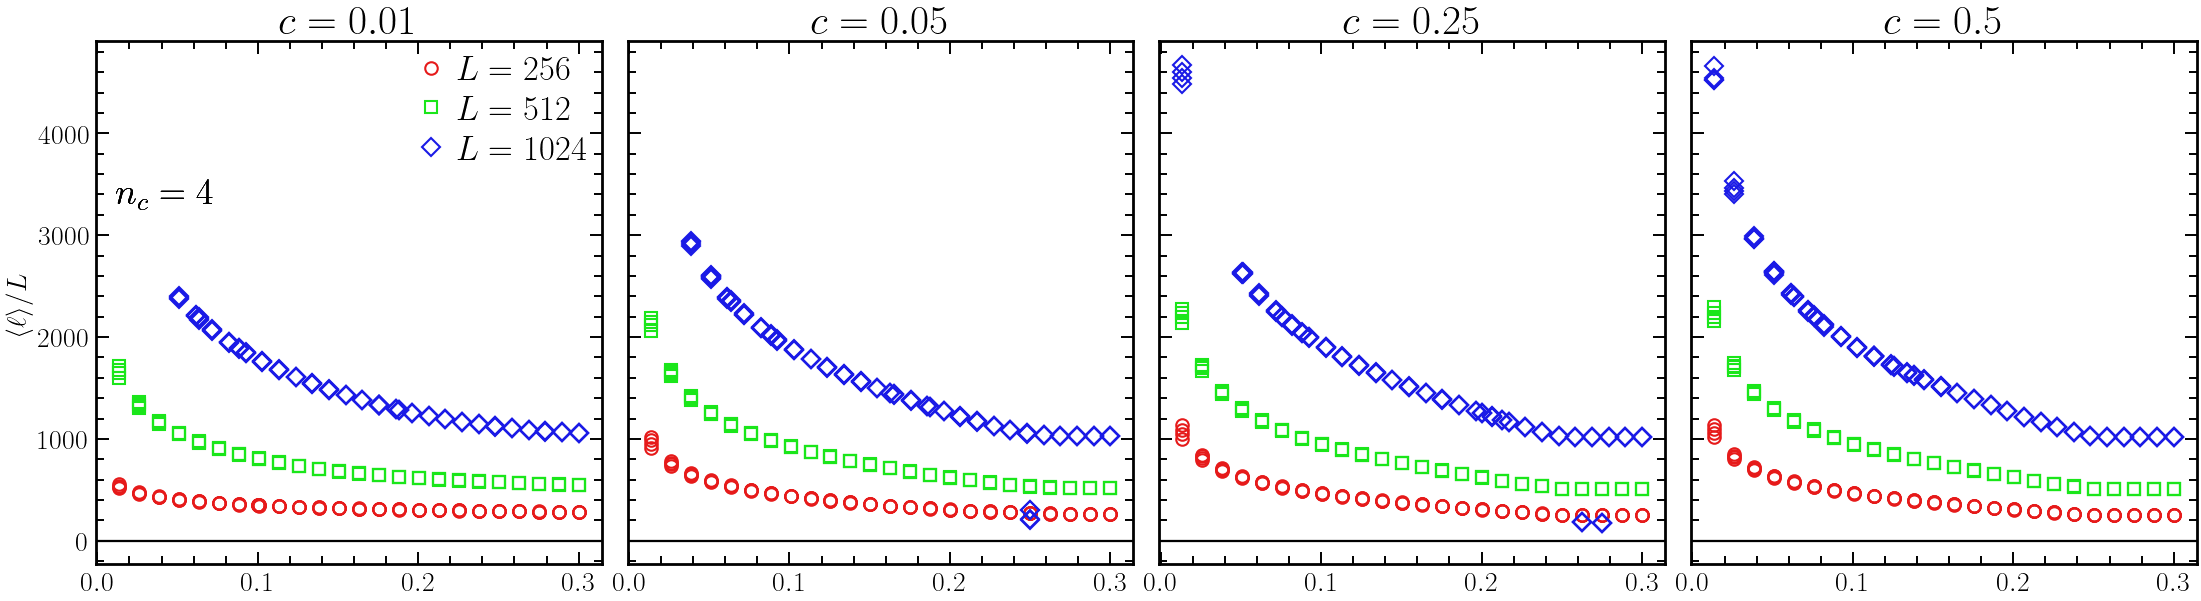

In [34]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 4
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T']
        pmean = df_b['shortest_path']
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle \ell \rangle/L$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
plt.show()

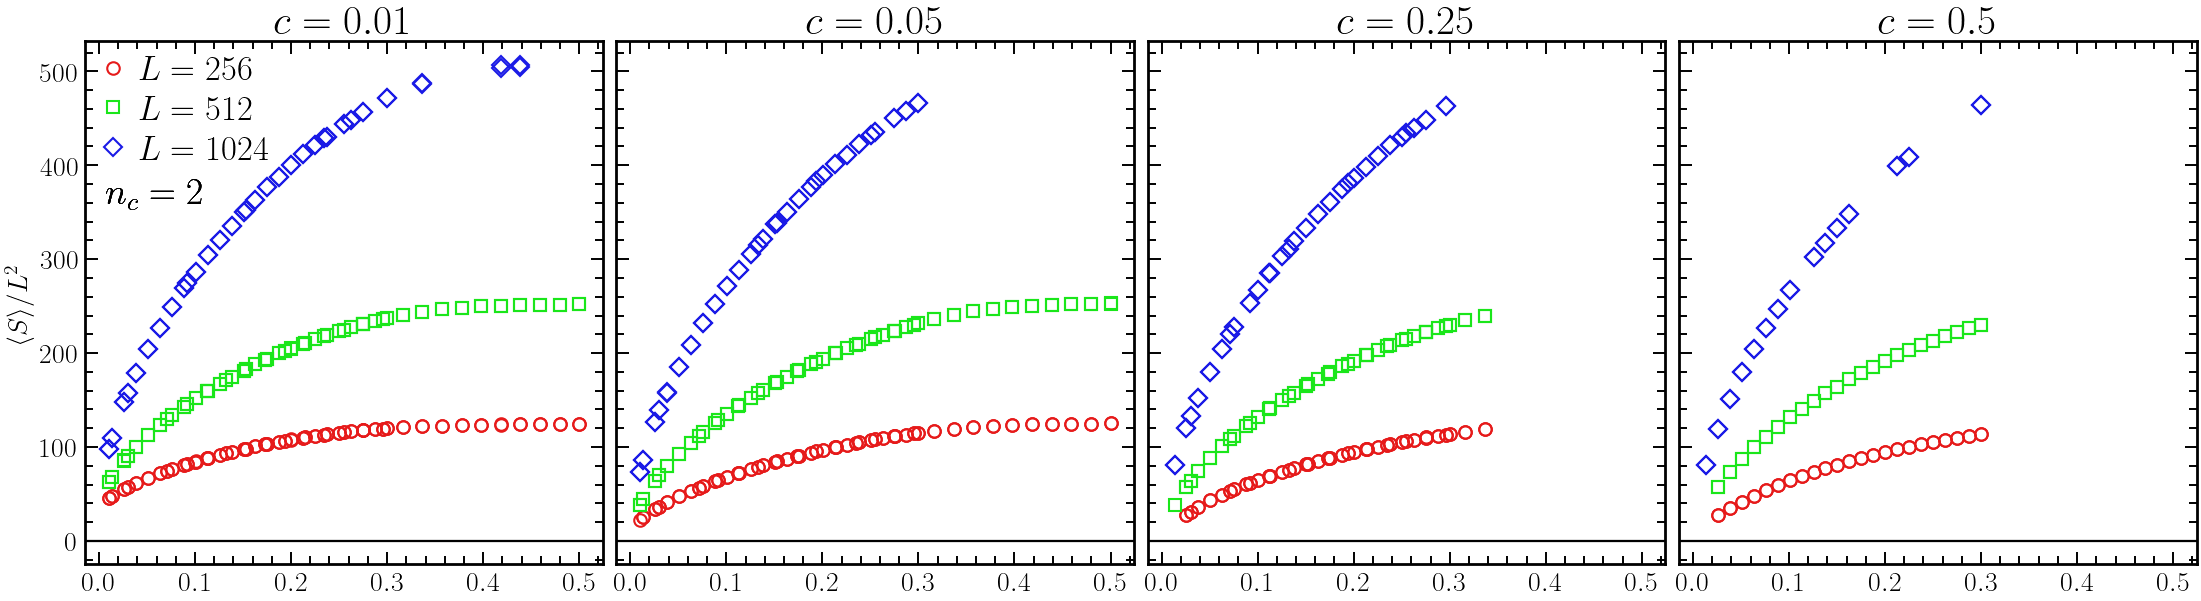

In [35]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 2
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T']
        pmean = df_b['S_perc'] / L**2
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle S \rangle/L^2$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
plt.show()

In [ ]:
df_min[(df_min['k']==1.0e-06) & (df_min['P0']==0.1) & (df_min['L']>128)]

In [ ]:
k_lst = [1.0e-04, 5.0e-05, 1.0e-05, 5.0e-05, 6.0e-06]
L = 256
nc = 2
dim = 3
rho = 1/nc
A = L**2
k=6.0e-06
Nt = 655
rho = 0.25
# acumula todas as series de TODOS os nc para definir um t_eq GLOBAL por subplot (por L)
all_series = []  # lista de dicts: {nc, i, t, pt, sem}
num_seeds_by_nc = {}

fig, ax = plt.subplots(
    1, 1, figsize=(15, 6),
    sharey=True,
    sharex=True,
    constrained_layout=True
)
pc = 0.24881182
orders, num_seeds = read_mean_json(nc, dim, L, Nt, k, rho)
num_seeds_by_nc[nc] = num_seeds

if isinstance(orders, dict):
    if "0" in orders:
        orders = [orders[str(i)] for i in range(nc)]
    else:
        orders = [orders[i] for i in range(nc)]

for i in range(nc):
    d = orders[i]["data"]
    t = np.array(d["time"], dtype=float)
    pt = np.array(d["pt_mean"], dtype=float)
    pt_sem = np.array(d["pt_sem"], dtype=float)
    all_series.append({"nc": nc, "i": i, "t": t, "pt": pt, "sem": pt_sem})

# t_eq: calcula t0 por série e pega o máximo (para usar em todas as curvas do subplot)
t0_ind = []
for s in all_series:
    t, pt, sem = s["t"], s["pt"], s["sem"]
    idx0_i = detect_equilibrium_start_with_errors(
        t, pt, sem, w=40, consec=6, z=2.0, chi2r_max=2.0
    )
    t0_ind.append(float(t[idx0_i]))
t0_global = float(max(t0_ind))

print(f"t0 GLOBAL (usado para TODAS no subplot L={L}): {t0_global:.2f}")
ls = '-'
color = 'k'
lw_dados = 1.4
lw_pc = 1.4
# plot: cor = i, linestyle = nc

for s in all_series:
    nc, i = s["nc"], s["i"]
    t, pt, sem = s["t"], s["pt"], s["sem"]

    ax.plot(t, pt, ls=ls, color=color, lw=lw_dados)
    ax.fill_between(t, pt - sem, pt + sem, alpha=0.12, color=color)

ax.axhline(y=pc, linestyle="-", color="darkviolet", lw=lw_pc, alpha=0.9, zorder=5)

path = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k:.1e}/rho_{rho:.4e}/data/"
#random_sample = path + "light_seed_2129561910_ts_20260323T143847_P0_0.10_p0_1.00.json"
random_sample = select_random_json(path, 1.0)
ts = read_experiment_json(random_sample)
t = np.asarray(ts['results']['order_percolation 1']['data']['time'])
pt = np.asarray(ts['results']['order_percolation 1']['data']['pt'])
ax.plot(t, pt)
print(pt)
plt.show()